<a href="https://colab.research.google.com/github/HeloisaGS/modelo-sir-recife/blob/main/SIR_catapora_recife.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Instalação e Carga de Pacotes

In [1]:
# Instalação dos pacotes, caso ainda não estejam instalados
if (!require(deSolve)) install.packages("deSolve")
if (!require(ggplot2)) install.packages("ggplot2")
if (!require(reshape2)) install.packages("reshape2")

# Carregamento das bibliotecas
library(deSolve)
library(ggplot2)
library(reshape2)

Loading required package: deSolve

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘deSolve’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: ggplot2

Loading required package: reshape2

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘reshape2’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘plyr’




## Definição do problema e parâmetros

**Doença estudada: Catapora (Varicela)**

A doença escolhida para o modelo é a catapora (varicela), causada pelo vírus Varicela-Zoster. A doença apresenta alta transmissibilidade e pode ser transmitida por contato direto e por partículas respiratórias. Segundo o Ministério da Saúde, a transmissão pode ocorrer de 1 a 2 dias antes do aparecimento das lesões até aproximadamente 6 dias depois, quando as lesões já estão em fase de crosta.
Para possibilitar a utilização do modelo SIR clássico, será considerada uma população homogênea, sem divisão por faixa etária, vacinação, localização geográfica ou diferentes níveis de contato social.
A população considerada será a população estimada do Recife em 2025, de 1.588.376 habitantes.
Será considerado um cenário hipotético de início de surto com 10 indivíduos infectados.


In [2]:
# 3. Determine os parâmetros iniciais que serão usados no modelo SIR e justifique a escolha.

# População estimada do Recife em 2025
N_pop <- 1588376

# Casos iniciais
I0 <- 10

# Indivíduos suscetíveis inicialmente
S0 <- N_pop - I0

# Indivíduos removidos/recuperados inicialmente
R0_inicial <- 0

# Duração média considerada do período infeccioso
D <- 7

# Taxa de recuperação
gamma <- 1 / D

# Número básico de reprodução adotado
R0 <- 9

# Taxa de transmissão
beta <- R0 * gamma

# Período da simulação
times <- seq(from = 0, to = 90, by = 1)

# Exibição dos parâmetros
cat("População:", N_pop, "\n")
cat("Casos iniciais:", I0, "\n")
cat("Gamma:", gamma, "\n")
cat("R0:", R0, "\n")
cat("Beta:", beta, "\n")

População: 1588376 
Casos iniciais: 10 
Gamma: 0.1428571 
R0: 9 
Beta: 1.285714 


## Definição do modelo SIR

In [3]:
sir_catapora <- function(time, state, parameters) {

  with(as.list(c(state, parameters)), {

    dS <- -beta * S * I / (S + I + R)

    dI <- beta * S * I / (S + I + R) - gamma * I

    dR <- gamma * I

    return(list(c(dS, dI, dR)))
  })
}

## Simulação do cenário base

In [4]:
initial_state <- c(
  S = S0,
  I = I0,
  R = R0_inicial
)

parameters <- c(
  beta = beta,
  gamma = gamma
)

resultado <- as.data.frame(
  ode(
    y = initial_state,
    times = times,
    func = sir_catapora,
    parms = parameters
  )
)

head(resultado)

,time,S,I,R
,<dbl>,<dbl>,<dbl>,<dbl>
1,0,1588366,10.00000,0.000000
2,1,1588342,31.35668,2.669627
3,2,1588267,98.32056,11.040536
4,3,1588030,308.25427,37.286479
5,4,1587290,966.09253,119.557964
6,5,1584974,3024.42340,377.258911


## Identificação do pico da epidemia

In [5]:
# 4. Implemente o modelo SIR e determine após quantos dias a doença atingirá o pico (Utilize os códigos construídos no curso).  Exiba o número de pessoas em cada compartimento (S, I, R) no pico.
indice_pico <- which.max(resultado$I)

dia_pico <- resultado$time[indice_pico]

S_pico <- resultado$S[indice_pico]
I_pico <- resultado$I[indice_pico]
R_pico <- resultado$R[indice_pico]

cat("Dia do pico:", dia_pico, "\n")
cat("Suscetíveis no pico:", round(S_pico), "\n")
cat("Infectados no pico:", round(I_pico), "\n")
cat("Recuperados no pico:", round(R_pico), "\n")

Dia do pico: 13 
Suscetíveis no pico: 113594 
Infectados no pico: 1009241 
Recuperados no pico: 465541 


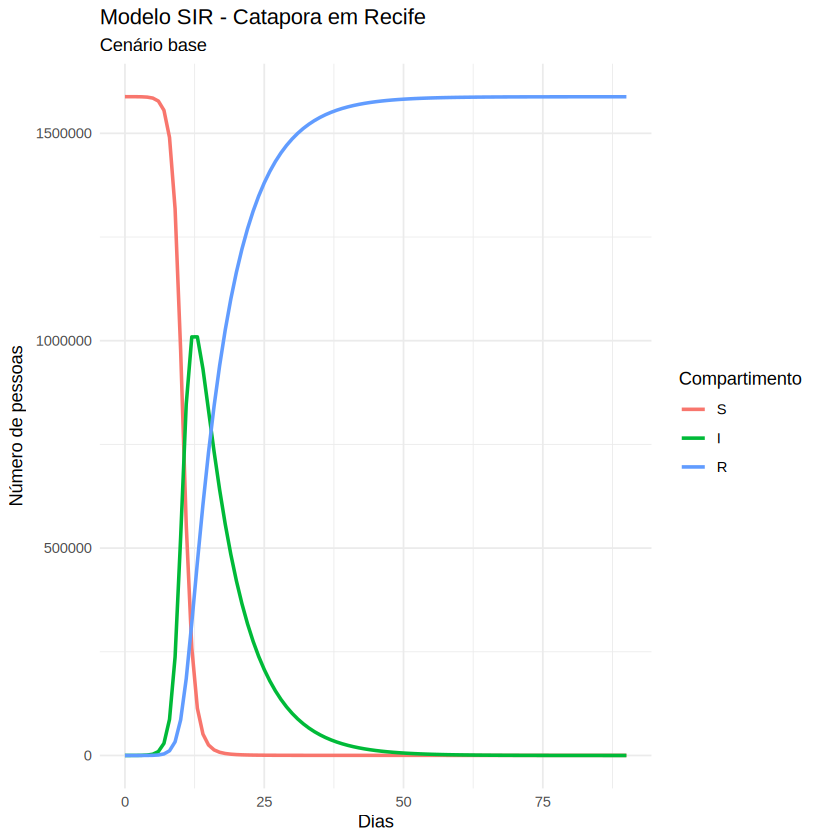

In [6]:
dados_longos <- melt(
  resultado,
  id.vars = "time",
  variable.name = "Compartimento",
  value.name = "Pessoas"
)

ggplot(dados_longos, aes(x = time, y = Pessoas, color = Compartimento)) +
  geom_line(linewidth = 1) +
  labs(
    title = "Modelo SIR - Catapora em Recife",
    subtitle = "Cenário base",
    x = "Dias",
    y = "Número de pessoas",
    color = "Compartimento"
  ) +
  theme_minimal()

## Variação dos parâmetros e gráficos

In [7]:
rodar_sir <- function(beta, gamma, titulo) {

  estado_inicial <- c(
    S = S0,
    I = I0,
    R = R0_inicial
  )

  parametros <- c(
    beta = beta,
    gamma = gamma
  )

  resultado <- as.data.frame(
    ode(
      y = estado_inicial,
      times = times,
      func = sir_catapora,
      parms = parametros
    )
  )

  resultado_long <- melt(
    resultado,
    id.vars = "time",
    variable.name = "Compartimento",
    value.name = "Pessoas"
  )

  ggplot(
    resultado_long,
    aes(x = time, y = Pessoas, color = Compartimento)
  ) +
    geom_line(linewidth = 1) +
    labs(
      title = titulo,
      x = "Dias",
      y = "Número de pessoas",
      color = "Compartimento"
    ) +
    theme_minimal()
}

In [8]:
# 5.  Faça pelo menos 6 variações nas taxas de contaminação e recuperação (taxas iguais, uma fixa e a outra variando, ...) apresente os gráficos obtidos e comente os resultados.

grafico1 <- rodar_sir(
  beta = 1.286,
  gamma = 0.143,
  "1. Cenário base"
)

grafico2 <- rodar_sir(
  beta = 1.800,
  gamma = 0.143,
  "2. Maior taxa de transmissão"
)

grafico3 <- rodar_sir(
  beta = 0.800,
  gamma = 0.143,
  "3. Menor taxa de transmissão"
)

grafico4 <- rodar_sir(
  beta = 1.286,
  gamma = 0.286,
  "4. Recuperação mais rápida"
)

grafico5 <- rodar_sir(
  beta = 0.500,
  gamma = 0.500,
  "5. Beta e gamma iguais"
)

grafico6 <- rodar_sir(
  beta = 0.100,
  gamma = 0.143,
  "6. R0 menor que 1"
)

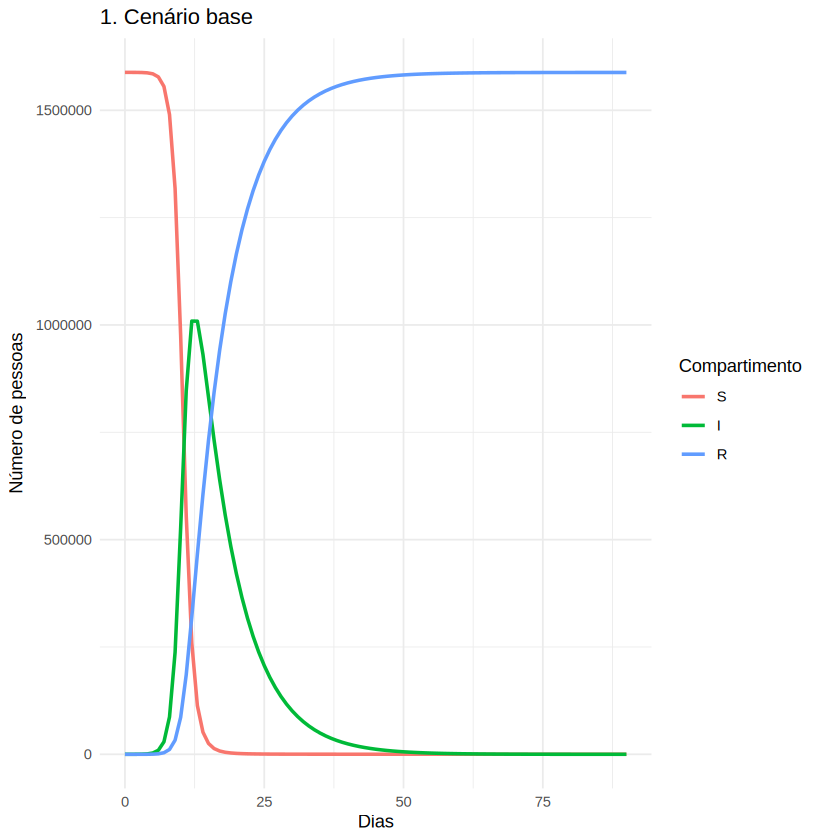

In [9]:
grafico1


### 1. Cenário Base ($\beta = 1.286$, $\gamma = 0.143$, $R_0 = 9$)


Com um $R_0$ elevado, a epidemia avança rapidamente. A curva verde (Infectados) cresce de forma acentuada, atingindo um pico de cerca de 1 milhão de pessoas ativas ao mesmo tempo em cerca de 12 a 13 dias. A população de suscetíveis ($S$) é rapidamente consumida, e quase $100\%$ da população termina recuperada ($R$).


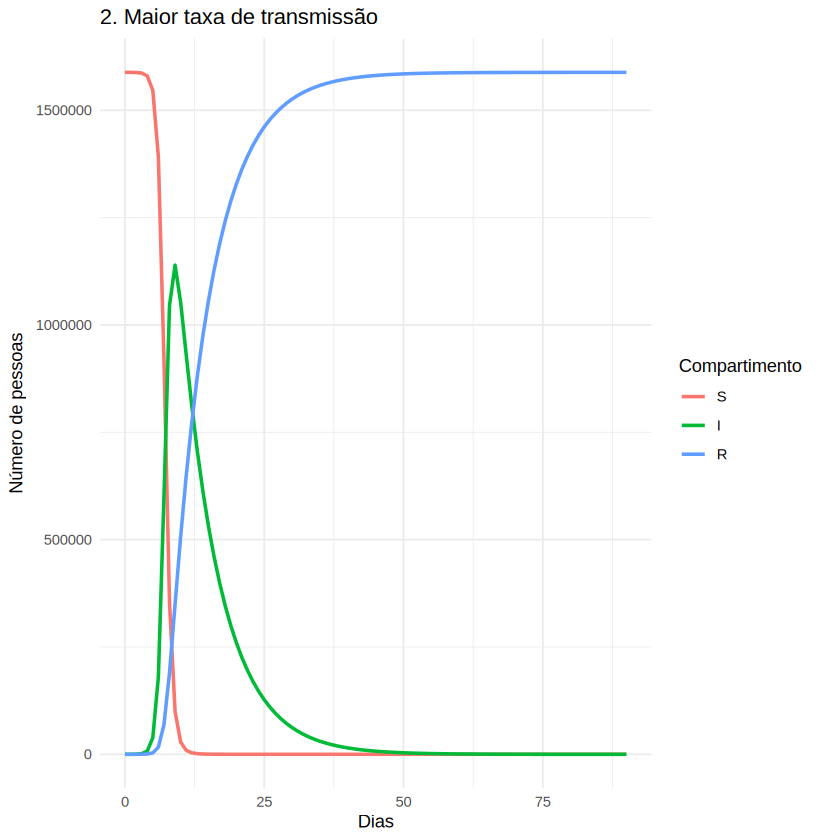

In [10]:
grafico2


### 2. Maior taxa de transmissão ($\beta = 1.800$, $\gamma = 0.143$, $R_0 \approx 12.6$)

Ao aumentar a taxa de contágio ($\beta$), a velocidade de disseminação do vírus se intensifica. O pico epidêmico é antecipado (ocorre por volta do dia 9 a 10) e atinge uma altura ainda maior (mais de 1,1 milhão de infectados simultâneos).

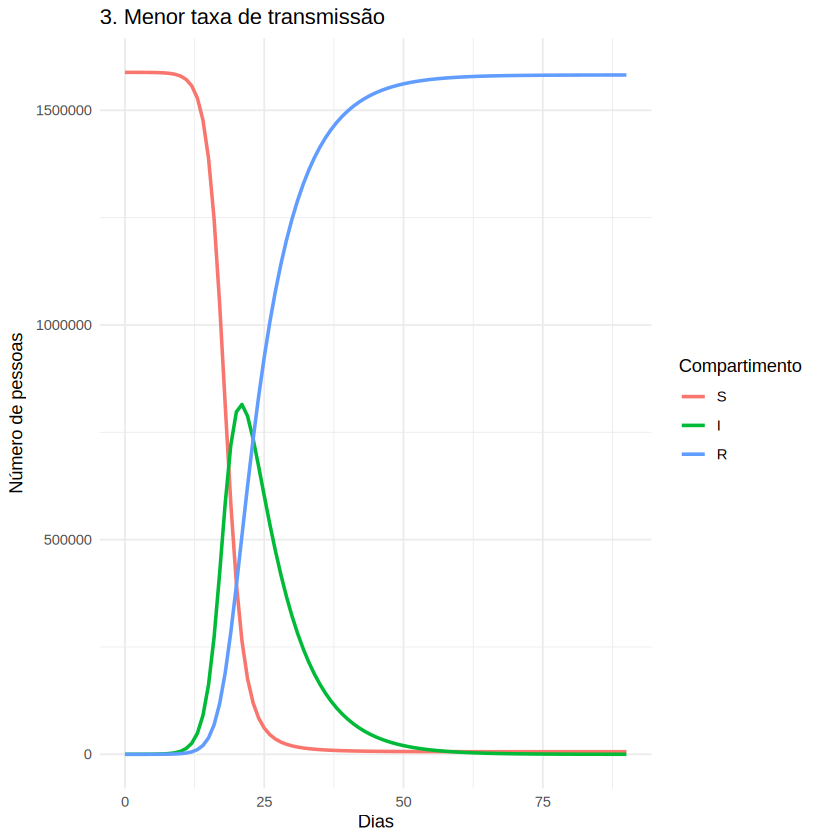

In [11]:
grafico3


### 3. Menor taxa de transmissão ($\beta = 0.800$, $\gamma = 0.143$, $R_0 \approx 5.6$)

Ocorreu o efeito de "achatamento da curva". O pico de infectados foi reduzido para cerca de 800 mil pessoas e adiantou-se mais para a frente (ocorrendo por volta do dia 21). Isso demonstra como medidas que reduzem o contato/transmissão atrasam a evolução da doença.

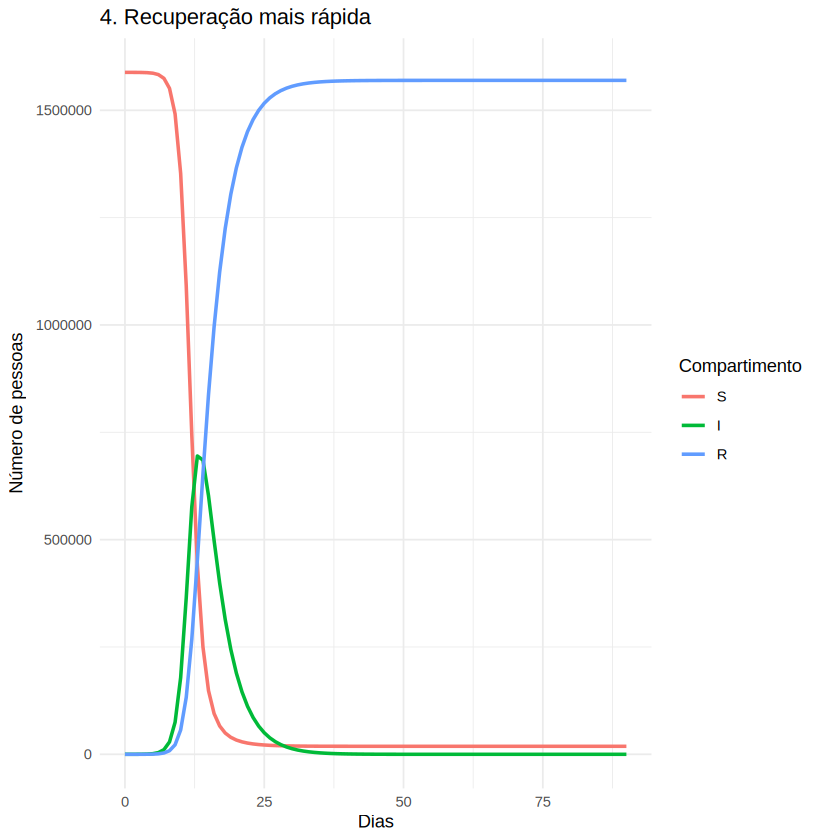

In [12]:
grafico4


### 4. Recuperação mais rápida ($\beta = 1.286$, $\gamma = 0.286$, $R_0 = 4.5$)

Ao dobrar a taxa de recuperação ($\gamma$), o tempo médio de infecção cai pela metade ($D = 3,5$ dias). Como o indivíduo passa menos tempo transmitindo, o $R_0$ efetivo cai de 9 para 4.5, resultando em um pico de infectados significativamente menor (ao redor de 700 mil) se comparado ao cenário base.

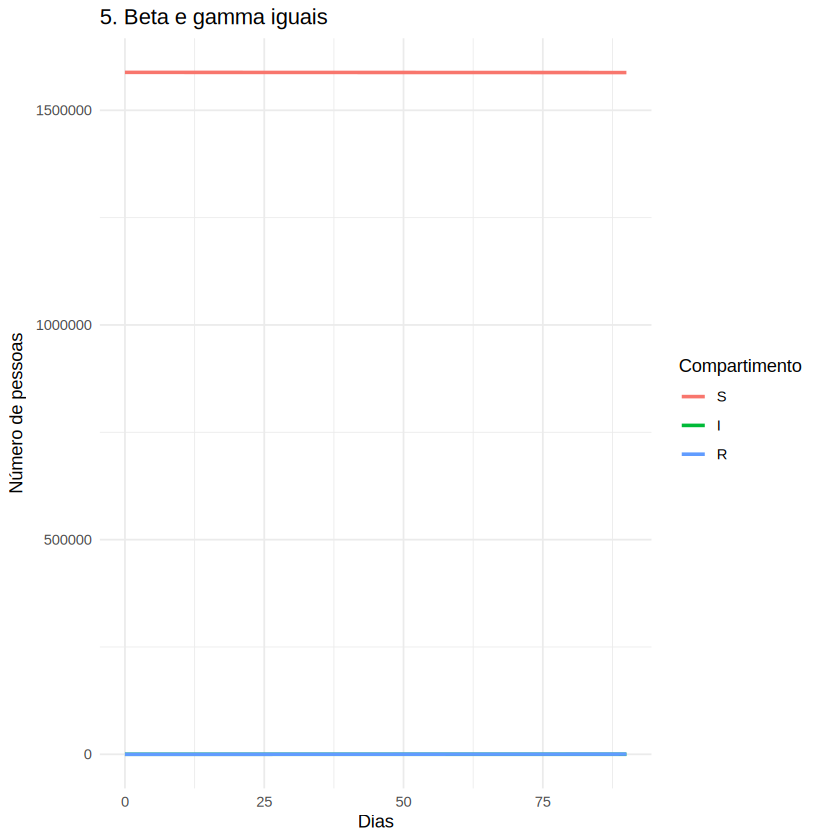

In [13]:
grafico5


### 5. Beta e gamma iguais ($\beta = 0.500$, $\gamma = 0.500$, $R_0 = 1$)

Como $R_0 = 1$, cada indivíduo infectado transmite a doença para em média apenas 1 pessoa antes de se recuperar. O limiar epidêmico não é ultrapassado, impedindo que a doença ganhe tração. As linhas se mantêm constantes: os sucetiveis $S$ praticamente idêntico a população no topo e os infectados $I$ e recuperados próximo de zero.

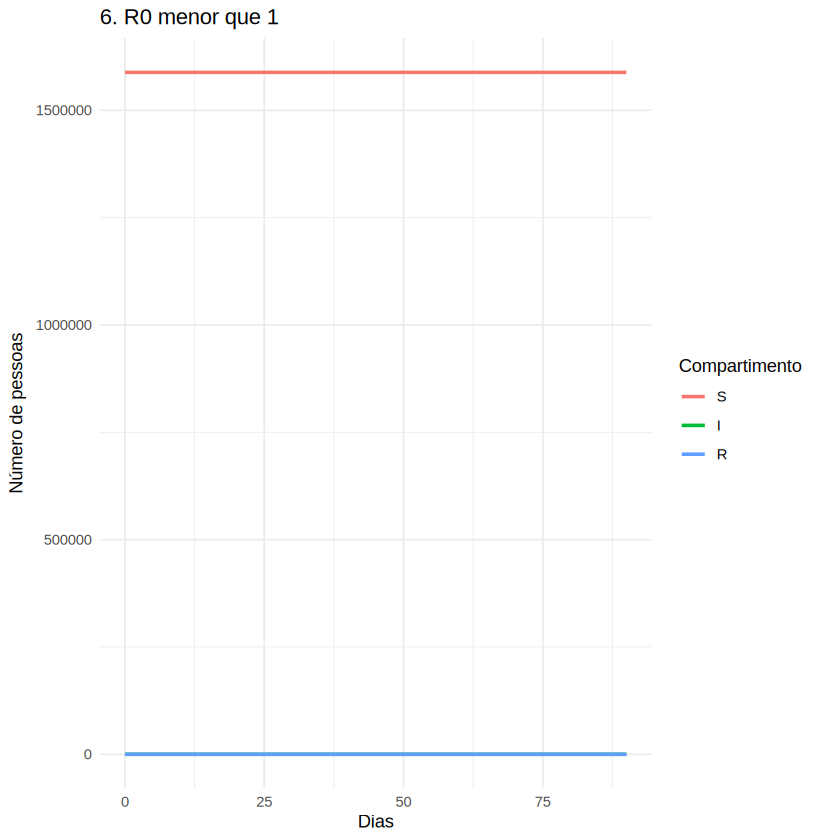

In [14]:
grafico6

### 6. R0 menor que 1 ($\beta = 0.100$, $\gamma = 0.143$, $R_0 \approx 0.7$)

A taxa de remoção/recuperação é maior que a taxa de transmissão ($\gamma > \beta$). O vírus não consegue se sustentar na população. Os 10 casos iniciais se recuperam sem gerar um surto, e a curva epidêmica se mantém extinta desde o primeiro dia.

## Limitações do modelo

* **Faixa etária:** A catapora afeta predominantemente crianças. O modelo SIR assume que todos os indivíduos da população possuem a mesma taxa de contato, ignorando que ambientes como creches e escolas apresentam taxas de transmissão muito superiores ao restante da comunidade.

* **Vacinação:** O Brasil disponibiliza a vacina contra a catapora no Calendário Nacional de Vacinação do SUS. O modelo SIR padrão não contempla um compartimento de Vacinados ($V$), o que leva a uma superestimação do número inicial de indivíduos realmente suscetíveis ($S_0$).
* **Imunidade passiva e reativação:**  O SIR não considera a imunidade passiva temporária conferida por mães imunes aos bebês, nem a reativação tardia do vírus em adultos sob a forma de Herpes-Zóster.
* **Incubação:** O modelo SIR assume que um indivíduo recém-infectado passa a transmitir a doença instantaneamente. Na realidade, a catapora possui um período de incubação longo (de 4 a 16 dias) em que o indivíduo carrega o vírus sem apresentar sintomas e sem transmitir. A transmissão só começa de 1 a 2 dias antes do aparecimento das feridas na pele e se estende por cerca de 6 dias depois (até a formação das crostas).

## Referências

https://www.gov.br/saude/pt-br/assuntos/saude-de-a-a-z/c/catapora-varicela

https://www.gov.br/saude/pt-br/assuntos/saude-de-a-a-z/c/catapora-varicela/situacao-epidemiologica

https://cidades.ibge.gov.br/brasil/pe/recife/panorama